# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


In [1]:
%pip install numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [18]:
from pathlib import Path

local_path = Path("titanic.csv")

if local_path.exists():
    df = pd.read_csv(local_path)
    print(f"Đã tải dữ liệu local: {local_path}")
else:
    try:
        df = sns.load_dataset("titanic")
        print("Đã tải từ seaborn.")
    except Exception:
        url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
        df = pd.read_csv(url)
        print("Đã tải từ kho seaborn-data.")

df.head()


Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [19]:
# 1a: in tỷ lệ missing của tất cả các cột
missing_all = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=False)

display(missing_all)

# 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = [
    "alive", "who", "adult_male", "class", "deck",
    "embark_town", "alone"
]

existing_leaky = [col for col in leaky if col in df.columns]
df = df.drop(columns=existing_leaky)

keep_cols = [
    "survived", "pclass", "sex", "age",
    "sibsp", "parch", "fare", "embarked"
]
df = df[keep_cols].copy()

print("Đã loại bỏ:", existing_leaky)
print("Các cột còn lại:", list(df.columns))


,missing_count,missing_percent
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22
sex,0,0.00
pclass,0,0.00
survived,0,0.00
fare,0,0.00
parch,0,0.00
sibsp,0,0.00


Đã loại bỏ: ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

`alive` chỉ là cách viết bằng chữ của chính nhãn `survived`: `yes` tương ứng `1`, còn `no` tương ứng `0`. Nếu giữ cột này, mô hình nhìn thấy đáp án ngay trong đầu vào. Accuracy có thể tiến sát 100%, nhưng mô hình không học quan hệ giữa tuổi, giới tính, hạng vé hoặc giá vé với khả năng sống sót. Khi dự đoán hành khách mới, cột `alive` chưa tồn tại nên mô hình không có giá trị sử dụng thực tế.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [20]:
# Hoàn thành 2: shape, info, describe
print(f"Số dòng: {df.shape[0]}")
print(f"Số cột: {df.shape[1]}")
print("Biến mục tiêu: survived")

print("\nThông tin DataFrame:")
df.info()

print("\nThống kê các biến số:")
display(df.describe())

print("\nThống kê các biến phân loại:")
display(df.describe(include=["object", "category"]))


Số dòng: 891
Số cột: 8
Biến mục tiêu: survived

Thông tin DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB

Thống kê các biến số:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Thống kê các biến phân loại:


C:\Users\tuank\AppData\Local\Temp\ipykernel_33220\2632481021.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=["object", "category"]))


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Trả lời 2 (biến số vs biến phân loại):**

- Biến mục tiêu: `survived`, nhãn nhị phân 0 hoặc 1.
- Biến số: `age`, `sibsp`, `parch`, `fare`.
- Biến phân loại: `sex`, `embarked`.
- Biến thứ tự: `pclass`. Cột này được lưu dưới dạng số nhưng các giá trị 1, 2, 3 biểu diễn hạng vé có thứ tự, không phải đại lượng liên tục.

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [21]:
# TODO 3: bảng missing (count + %)
missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})
missing_table = missing_table[missing_table["missing_count"] > 0]
missing_table = missing_table.sort_values("missing_percent", ascending=False)

display(missing_table)


,missing_count,missing_percent
age,177,19.87
embarked,2,0.22


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---:|---|---|
| `age` | 19.87% | Điền median, chỉ học median từ tập train | Tỷ lệ thiếu chưa quá lớn. Phân phối tuổi có lệch nhẹ và có một số giá trị lớn, nên median ổn định hơn mean. |
| `embarked` | 0.22% | Điền mode, chỉ học mode từ tập train | Đây là biến phân loại và chỉ thiếu 2 mẫu. Mode giữ nguyên loại dữ liệu và tránh xóa mẫu không cần thiết. |

Cột `deck` thiếu 77.22% nên đã bị loại ở Task 1. Tỷ lệ thiếu quá cao khiến việc điền giá trị tạo ra nhiều thông tin giả.

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [23]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    s = s.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((s < lower) | (s > upper)).sum())


def dem_outlier_zscore(s, nguong=3.0):
    s = s.dropna()
    z = np.abs(stats.zscore(s))
    return int((z > nguong).sum())

outlier_rows = []
for col in ["age", "fare"]:
    outlier_rows.append({
        "column": col,
        "IQR_outliers": dem_outlier_iqr(df[col]),
        "Zscore_outliers": dem_outlier_zscore(df[col])
    })

outlier_summary = pd.DataFrame(outlier_rows).set_index("column")
display(outlier_summary)


,IQR_outliers,Zscore_outliers
column,,
age,11,2
fare,116,20


**Trả lời 4 (quyết định với outlier của `fare`):**

Mình giữ các outlier của `fare`. Giá vé cao có thể phản ánh vé hạng nhất, cabin đắt hoặc vé mua chung cho một nhóm, nên đây chưa phải bằng chứng của lỗi nhập liệu. IQR đánh dấu 116 giá trị và Z-score đánh dấu 20 giá trị vì `fare` lệch phải mạnh. Thay vì xóa các quan sát hợp lệ, mình dùng `RobustScaler`, dựa trên median và IQR nên ít bị các giá trị cực lớn chi phối.


---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

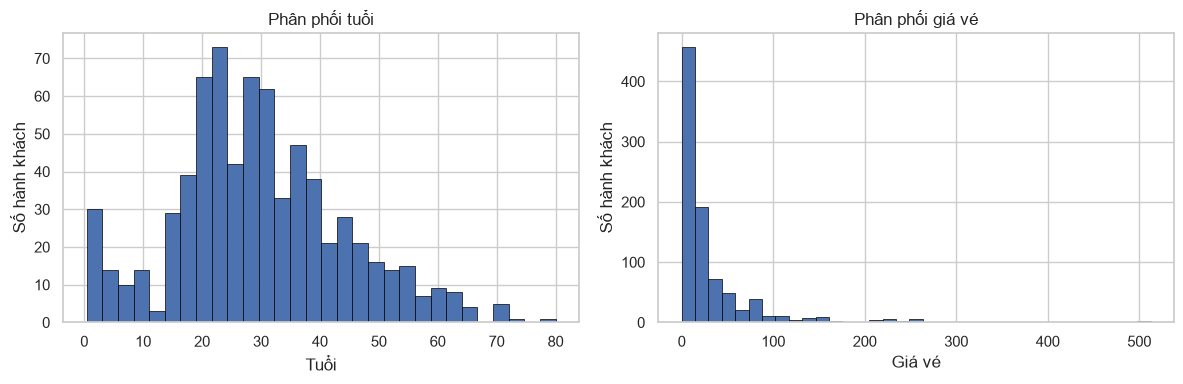

Skewness:
age     0.389
fare    4.787
dtype: float64


In [24]:
# TODO 5a: Histogram age & fare

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["age"].dropna(), bins=30, edgecolor="black", linewidth=0.5)
axes[0].set_title("Phân phối tuổi")
axes[0].set_xlabel("Tuổi")
axes[0].set_ylabel("Số hành khách")

axes[1].hist(df["fare"].dropna(), bins=35, edgecolor="black", linewidth=0.5)
axes[1].set_title("Phân phối giá vé")
axes[1].set_xlabel("Giá vé")
axes[1].set_ylabel("Số hành khách")

plt.tight_layout()
plt.show()

print("Skewness:")
print(df[["age", "fare"]].skew().round(3))

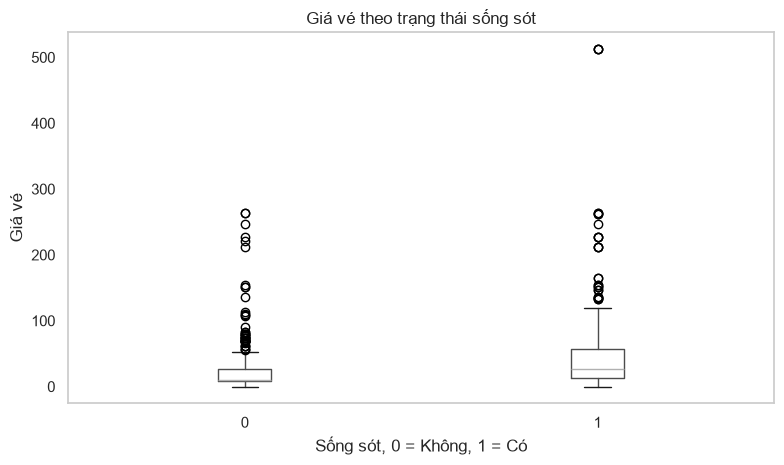

Median fare theo survived:
survived
0    10.5
1    26.0
Name: fare, dtype: float64


In [25]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column="fare", by="survived", ax=ax, grid=False)
plt.suptitle("")
ax.set_title("Giá vé theo trạng thái sống sót")
ax.set_xlabel("Sống sót, 0 = Không, 1 = Có")
ax.set_ylabel("Giá vé")
plt.tight_layout()
plt.show()

print("Median fare theo survived:")
print(df.groupby("survived")["fare"].median().round(2))

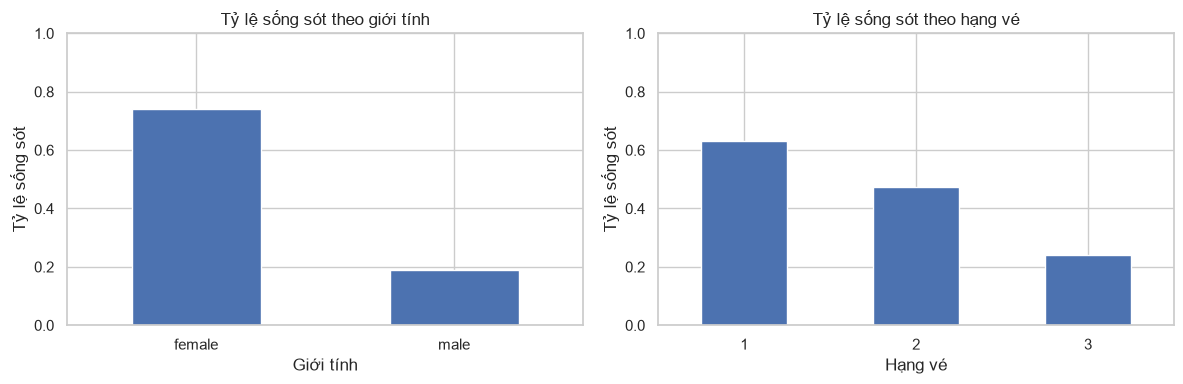

Tỷ lệ sống sót theo sex:
sex
female     74.2%
male      18.89%
Name: survived, dtype: str

Tỷ lệ sống sót theo pclass:
pclass
1    62.96%
2    47.28%
3    24.24%
Name: survived, dtype: str


In [26]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
survival_by_sex = df.groupby("sex")["survived"].mean()
survival_by_class = df.groupby("pclass")["survived"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

survival_by_sex.plot(kind="bar", ax=axes[0])
axes[0].set_title("Tỷ lệ sống sót theo giới tính")
axes[0].set_xlabel("Giới tính")
axes[0].set_ylabel("Tỷ lệ sống sót")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=0)

survival_by_class.plot(kind="bar", ax=axes[1])
axes[1].set_title("Tỷ lệ sống sót theo hạng vé")
axes[1].set_xlabel("Hạng vé")
axes[1].set_ylabel("Tỷ lệ sống sót")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print("Tỷ lệ sống sót theo sex:")
print((survival_by_sex * 100).round(2).astype(str) + "%")
print("\nTỷ lệ sống sót theo pclass:")
print((survival_by_class * 100).round(2).astype(str) + "%")

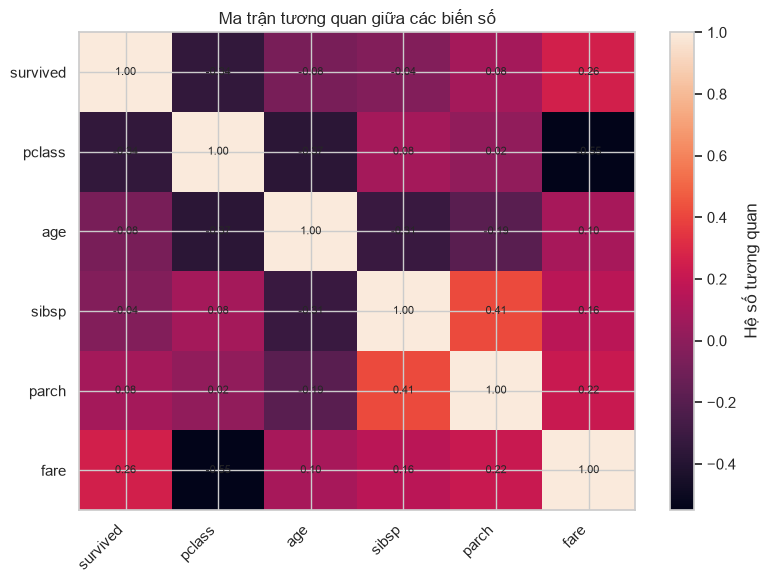

Tương quan với survived:
pclass     -0.338481
age        -0.077221
sibsp      -0.035322
parch       0.081629
fare        0.257307
survived    1.000000
Name: survived, dtype: float64


In [27]:
# TODO 5d: Heatmap correlation
corr = df.select_dtypes(include="number").corr()

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(corr.to_numpy(), aspect="auto")
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)), corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(image, ax=ax, label="Hệ số tương quan")
ax.set_title("Ma trận tương quan giữa các biến số")
plt.tight_layout()
plt.show()

print("Tương quan với survived:")
print(corr["survived"].sort_values())

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram: `age` lệch phải nhẹ với skewness khoảng 0.39. `fare` lệch phải rất mạnh với skewness khoảng 4.79; phần lớn hành khách trả giá vé thấp, còn một số ít có giá vé rất cao.
- Boxplot: nhóm sống sót có median `fare` khoảng 26.00, cao hơn nhóm không sống sót khoảng 10.50. Hai nhóm đều có outlier, đặc biệt ở nhóm sống sót.
- Bar survival: nữ có tỷ lệ sống sót khoảng 74.20%, nam khoảng 18.89%, chênh 55.31 điểm phần trăm. Hạng 1 đạt khoảng 62.96%, hạng 2 đạt 47.28%, hạng 3 chỉ đạt 24.24%.
- Heatmap: trong các biến số, `pclass` có tương quan tuyệt đối mạnh nhất với `survived`, r khoảng -0.34. `fare` có tương quan dương khoảng 0.26. `pclass` và `fare` tương quan âm khá rõ, r khoảng -0.55.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [28]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns="survived")
y = df["survived"]

# Tách 15% làm test
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# 15% toàn bộ dữ liệu tương ứng 15/85 của phần tạm còn lại
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp,
    test_size=0.15 / 0.85,
    random_state=42,
    stratify=y_tmp
)

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)

for name, target in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"{name}: tỷ lệ survived = {target.mean():.4f}")


Train/Val/Test: (623, 7) (134, 7) (134, 7)
Train: tỷ lệ survived = 0.3836
Validation: tỷ lệ survived = 0.3881
Test: tỷ lệ survived = 0.3806


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [29]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer([
    ("num", pipe_so, num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
], verbose_feature_names_out=False)

# Fit CHỈ trên train
preprocess.fit(X_train)

X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

feature_names = list(preprocess.get_feature_names_out())

print("Shape sau biến đổi:")
print("Train:", X_train_t.shape)
print("Validation:", X_val_t.shape)
print("Test:", X_test_t.shape)
print("\nTên đặc trưng sau biến đổi:")
print(feature_names)

# Kiểm tra không còn missing sau preprocessing
print("\nTổng NaN sau biến đổi:")
print("Train:", np.isnan(X_train_t).sum())
print("Validation:", np.isnan(X_val_t).sum())
print("Test:", np.isnan(X_test_t).sum())


Shape sau biến đổi:
Train: (623, 10)
Validation: (134, 10)
Test: (134, 10)

Tên đặc trưng sau biến đổi:
['age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'pclass']

Tổng NaN sau biến đổi:
Train: 0
Validation: 0
Test: 0


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

`fit` học median để điền `age`, mode để điền `embarked`, các tham số của `RobustScaler` và danh mục của `OneHotEncoder`. Nếu fit trên toàn bộ dữ liệu, các thống kê của validation và test đã tham gia vào quá trình chuẩn bị mô hình. Khi đó test không còn là dữ liệu chưa từng được nhìn thấy và điểm đánh giá bị lạc quan. Fit trên train rồi chỉ transform validation và test giữ đúng vai trò đánh giá độc lập của hai tập này.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [30]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
class_distribution = pd.DataFrame({
    "count": df["survived"].value_counts().sort_index(),
    "percent": (df["survived"].value_counts(normalize=True).sort_index() * 100).round(2)
})
class_distribution.index.name = "survived"
display(class_distribution)

,count,percent
survived,,
0,549,61.62
1,342,38.38


**Trả lời 8:**

1. Target mất cân bằng ở mức vừa: lớp 0 chiếm 61.62%, lớp 1 chiếm 38.38%. Đây không phải mất cân bằng cực đoan, nhưng đủ để Accuracy thiên về lớp không sống sót.
2. Accuracy gây hiểu nhầm khi mô hình chủ yếu dự đoán lớp đông. Ví dụ, dự đoán mọi hành khách đều không sống sót vẫn đạt khoảng 61.62% Accuracy nhưng Recall của lớp sống sót bằng 0.
3. Mình ưu tiên F1-score vì cần cân bằng Precision và Recall cho lớp sống sót. Mình vẫn báo cáo Accuracy, Precision và Recall riêng để thấy mô hình đang đánh đổi loại lỗi nào.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Trong các biến số, `pclass` liên hệ mạnh nhất với sống sót, hệ số tương quan khoảng -0.338. Tỷ lệ sống sót giảm từ 62.96% ở hạng 1 xuống 24.24% ở hạng 3.
2. `sex` tạo khác biệt lớn nhất khi xét theo nhóm: nữ sống sót 74.20%, nam 18.89%, chênh 55.31 điểm phần trăm.
3. Sau khi bỏ `deck` vì thiếu 77.22%, cột thiếu nhiều nhất còn lại là `age` với 19.87%. Mình điền median bằng thống kê chỉ học trên train. `embarked` chỉ thiếu 0.22% và được điền mode.
4. `fare` lệch phải mạnh, skewness khoảng 4.79. IQR phát hiện 116 outlier và Z-score phát hiện 20. Mình giữ chúng vì có thể là vé hợp lệ, rồi dùng `RobustScaler` để giảm ảnh hưởng của giá trị cực lớn.
5. Target có tỷ lệ 61.62% không sống sót và 38.38% sống sót. Vì vậy Accuracy chưa đủ; F1, Precision và Recall cần được theo dõi cùng nhau.
6. `age`, `sibsp`, `parch`, `fare` cần impute và scaling. `sex`, `embarked` cần One-Hot Encoding. `pclass` được giữ như biến thứ tự.
7. Một điểm đáng chú ý là median giá vé của nhóm sống sót khoảng 26.00, cao hơn nhiều so với 10.50 của nhóm không sống sót. Điều này phù hợp với chênh lệch sống sót theo hạng vé.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

,passengers,survival_rate,survival_rate_percent
family_size,,,
1,537,0.303538,30.35
2,161,0.552795,55.28
3,102,0.578431,57.84
4,29,0.724138,72.41
5,15,0.200000,20.00
6,22,0.136364,13.64
7,12,0.333333,33.33
8,6,0.000000,0.00
11,7,0.000000,0.00


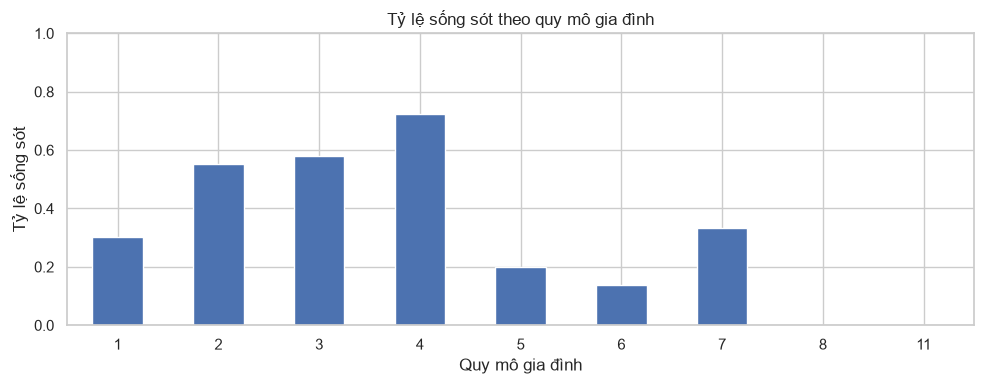

Tương quan family_size với survived: 0.017


In [32]:
# Bonus: feature engineering family_size
bonus_df = df.copy()
bonus_df["family_size"] = bonus_df["sibsp"] + bonus_df["parch"] + 1

family_summary = bonus_df.groupby("family_size").agg(
    passengers=("survived", "size"),
    survival_rate=("survived", "mean")
)
family_summary["survival_rate_percent"] = (family_summary["survival_rate"] * 100).round(2)

display(family_summary)

fig, ax = plt.subplots(figsize=(10, 4))
family_summary["survival_rate"].plot(kind="bar", ax=ax)
ax.set_title("Tỷ lệ sống sót theo quy mô gia đình")
ax.set_xlabel("Quy mô gia đình")
ax.set_ylabel("Tỷ lệ sống sót")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print("Tương quan family_size với survived:", round(bonus_df[["family_size", "survived"]].corr().iloc[0, 1], 3))

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
